In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/Hst1_self_asso/analysis/'

cm = 1/2.54
font = 8
font_label = 10
plt.rcParams['font.family'] = 'Helvetica'

colors = ['darkblue', 'aquamarine', 'darkorange']
cmap = LinearSegmentedColormap.from_list('mycmap', colors)
amount = 100
color_list = cmap(np.linspace(0, 1, amount))

In [3]:
files = ['1_2_full.xvg', '1_3_full.xvg', '1_4_full.xvg', '2_3_full.xvg', '2_4_full.xvg', '3_4_full.xvg']
temp = np.genfromtxt((work_dir + '1_2_full.xvg'), usecols=(1), unpack=True, skip_header=24)
dist_array = np.zeros((len(temp), 6))

counter = 0
for file in files:
    temp = np.genfromtxt((work_dir + file), usecols=(1), unpack=True, skip_header=24)
    dist_array[:, counter] = temp
    counter += 1
print(dist_array)

[[0.222 1.179 0.19  0.351 1.204 2.768]
 [0.205 1.15  0.22  0.273 1.196 2.842]
 [0.225 1.18  0.254 0.308 1.067 2.928]
 ...
 [0.179 5.154 9.044 6.587 9.342 5.791]
 [0.171 5.096 9.059 6.51  9.23  5.678]
 [0.183 5.006 8.854 6.657 9.062 5.735]]


In [4]:
cutoff_list = []
neighbour_counts = []
cutoff = 0.1
while cutoff <= 0.5:
    counter = 0
    for entry in dist_array:
        for point in entry:
            if point <= cutoff:
                counter += 1
    neighbour_counts.append(counter/len(temp))
    cutoff_list.append(cutoff)
    cutoff += 0.01

count_per_frames = []
for entry in dist_array:
    counter = 0
    for point in entry:
        if point <= 0.225:
            counter += 1
    count_per_frames.append(counter)
complex_types = np.unique(np.array(count_per_frames))
complex_counts = np.zeros_like(complex_types)

for entry in np.array(count_per_frames):
    if entry == 0:
        complex_counts[0] += 1
    elif entry == 1:
        complex_counts[1] += 1
    elif entry == 2:
        complex_counts[2] += 1
    elif entry == 3:
        complex_counts[3] += 1

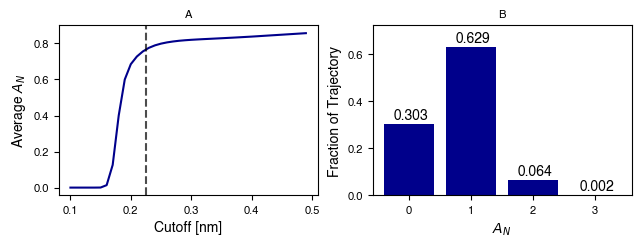

In [5]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=((16*cm), (6*cm)), layout='constrained')
ax[0].plot(cutoff_list, neighbour_counts, color=color_list[0])
ax[0].axvline(0.225, color='black', alpha=0.7, linestyle='--')
ax[0].tick_params(labelsize=font)
ax[0].set_xlabel('Cutoff [nm]', fontsize=font_label)
ax[0].set_ylabel('Average $A_{N}$', fontsize=font_label)
ax[0].set_title('A', fontsize=font)

ax[1].bar(complex_types, (complex_counts/sum(complex_counts)), color=color_list[0])
ax[1].tick_params(labelsize=font)
ax[1].set_xlabel('$A_{N}$', fontsize=font_label)
ax[1].set_ylabel('Fraction of Trajectory', fontsize=font_label)
ax[1].set_title('B', fontsize=font)
ax[1].set_ylim(0, 0.72)

for nr in range(0, 4):
    ax[1].text((complex_types[nr] - 0.25), ((complex_counts[nr]/sum(complex_counts)) + 0.02), 
           str(complex_counts[nr]/sum(complex_counts))[0:5])
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_new_figures/Oligomer_check.pdf', dpi=1000)

In [6]:
monomer_frames = []
dimer_frames = []
trimer_frames = []
tetramer_frames = []
counter = 1
for frame in count_per_frames:
    if frame == 0:
        monomer_frames.append(counter)
    elif frame == 1:
        dimer_frames.append(counter)
    elif frame == 2:
        trimer_frames.append(counter)
    elif frame == 3:
        tetramer_frames.append(counter)
    counter += 1

def write_index(frames):
    counter = 0
    for frame in frames:
        if counter == 6:
            save.write('    ' + str(frame) + '\n')
            counter = 0
        else:
            save.write('    ' + str(frame))
            counter += 1
    save.write('\n')

with open((work_dir + 'decomp.ndx'), 'w') as save:
    save.write('[ Monomer ]' + '\n')
    write_index(monomer_frames)
    save.write('[ Dimer ]' + '\n')
    write_index(dimer_frames)
    save.write('[ Trimer ]' + '\n')
    write_index(trimer_frames)
    save.write('[ Tetramer ]' + '\n')
    write_index(tetramer_frames)